Step 1: Data Loading & Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
train = pd.read_csv('../data/dataset/train.csv')
test = pd.read_csv('../data/dataset/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (77299, 11)
Test shape: (41778, 10)


In [5]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [6]:
print(train.dtypes)
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nMissing values in test:")
print(test.isnull().sum())

Index              int64
geohash              str
day                int64
timestamp            str
demand           float64
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str
dtype: object

Missing values in train:
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Missing values in test:
Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64


In [7]:
train.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


Step 2 — Exploratory Data Analysis (EDA)

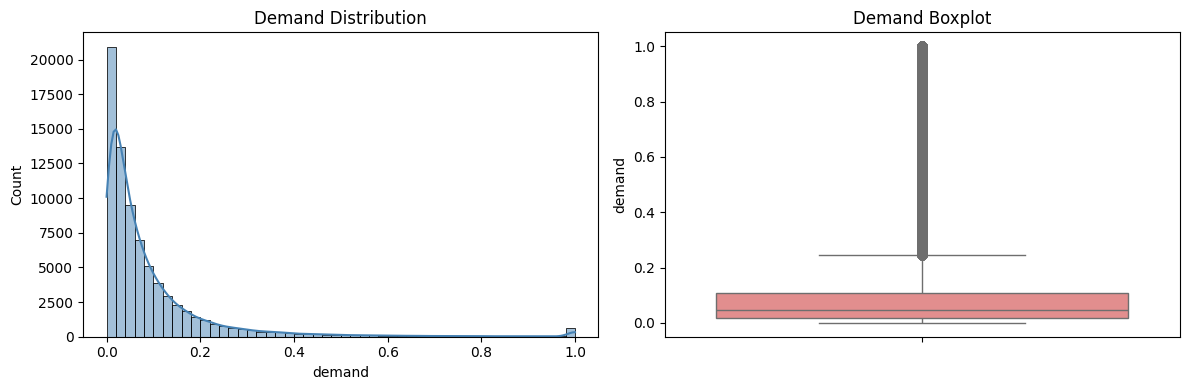

Demand stats:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Skewness: 3.7285172887316627


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train['demand'], bins=50, kde=True, color='steelblue')
plt.title('Demand Distribution')
plt.xlabel('demand')

plt.subplot(1, 2, 2)
sns.boxplot(y=train['demand'], color='lightcoral')
plt.title('Demand Boxplot')

plt.tight_layout()
plt.show()

print("Demand stats:")
print(train['demand'].describe())
print("Skewness:", train['demand'].skew())

In [9]:
cat_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

for col in cat_cols:
    print(f"\n{col} — {train[col].nunique()} unique values")
    print(train[col].value_counts().head(10))


geohash — 1249 unique values
geohash
qp094q    105
qp03pr    105
qp094r    105
qp03r0    105
qp03r2    105
qp03q9    105
qp03r1    105
qp03r3    105
qp03r9    105
qp03qd    105
Name: count, dtype: int64

RoadType — 3 unique values
RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64

LargeVehicles — 2 unique values
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

Landmarks — 2 unique values
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

Weather — 4 unique values
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64


In [10]:
print("Sample 'day' values:")
print(train['day'].value_counts().head(10))

print("\nSample 'timestamp' values:")
print(train['timestamp'].value_counts().head(10))

Sample 'day' values:
day
48    69427
49     7872
Name: count, dtype: int64

Sample 'timestamp' values:
timestamp
2:0     1778
1:45    1755
1:30    1750
1:15    1698
1:0     1668
0:30    1617
0:45    1609
0:15    1578
0:0     1534
6:0      928
Name: count, dtype: int64


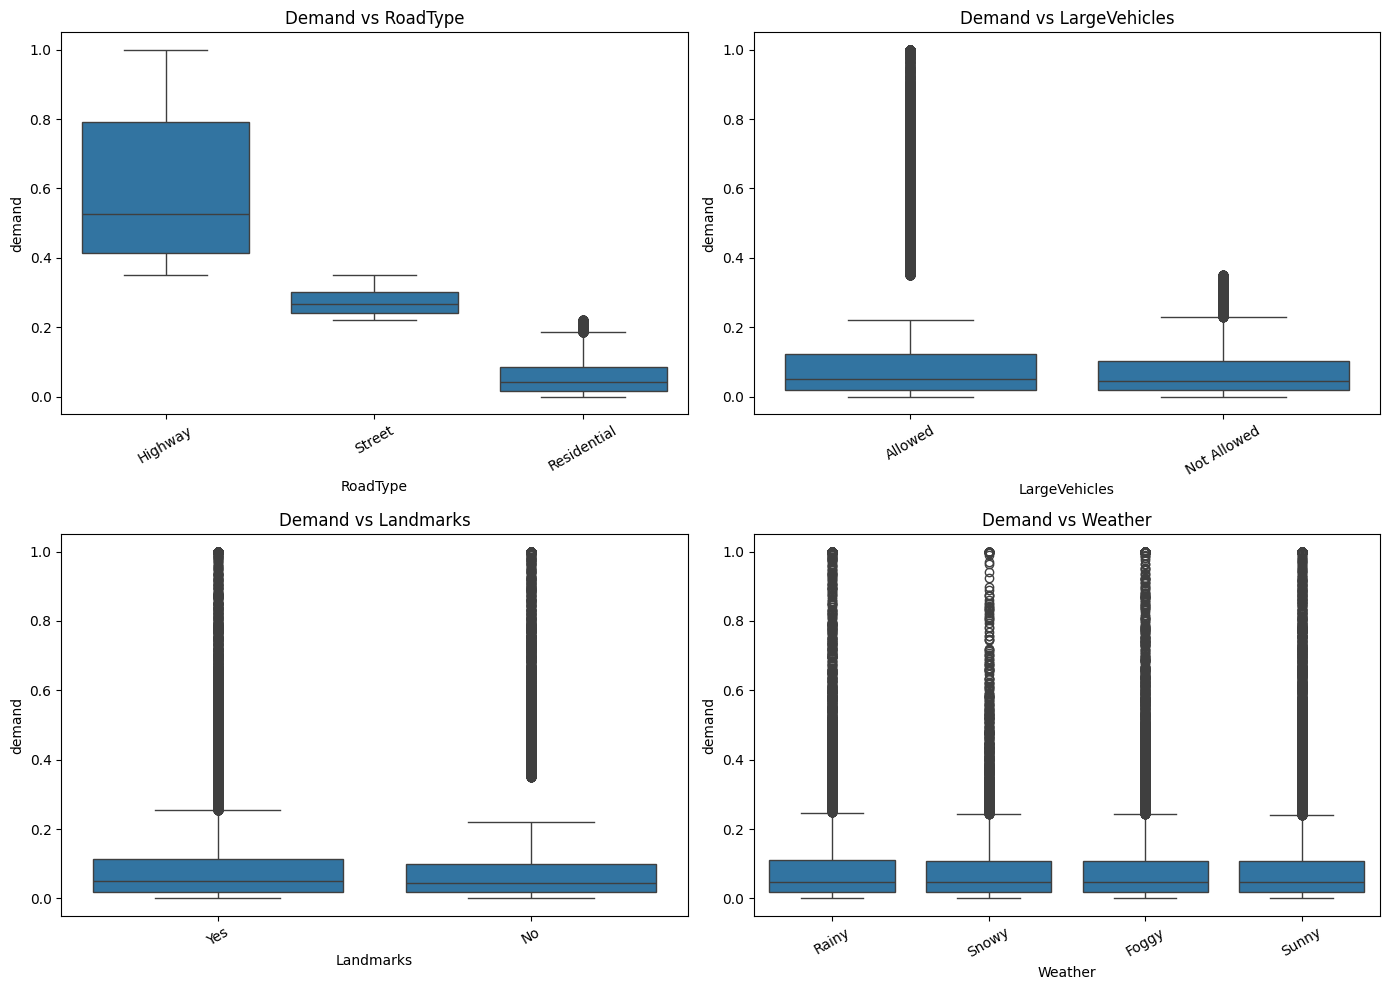

In [11]:
# Demand vs Categorical Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']):
    order = train.groupby(col)['demand'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='demand', order=order, ax=ax)
    ax.set_title(f'Demand vs {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

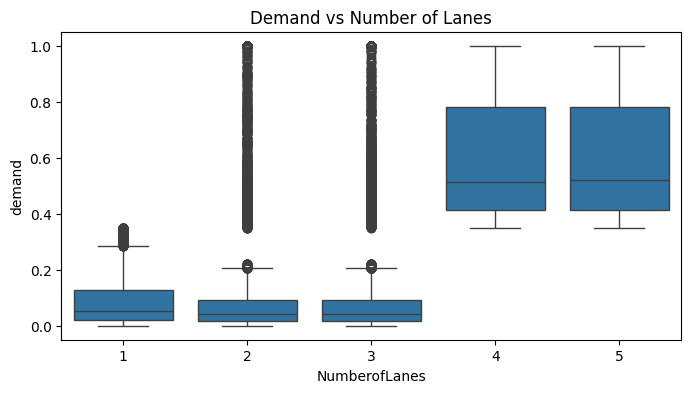

NumberofLanes
1    0.088104
2    0.077488
3    0.077859
4    0.602882
5    0.607556
Name: demand, dtype: float64


In [12]:
# Demand vs NumberofLanes
plt.figure(figsize=(8, 4))
sns.boxplot(data=train, x='NumberofLanes', y='demand')
plt.title('Demand vs Number of Lanes')
plt.show()

print(train.groupby('NumberofLanes')['demand'].mean())

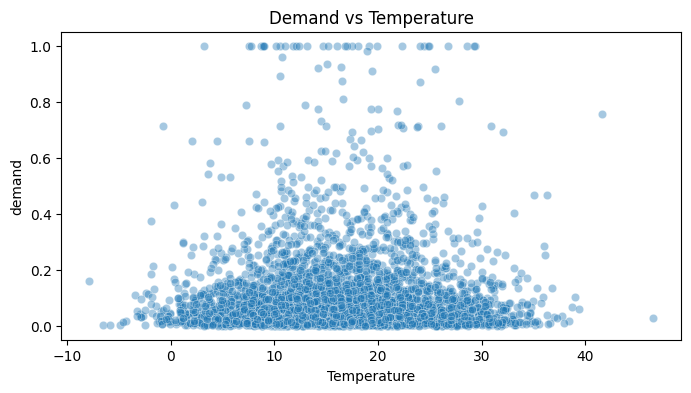

Temperature correlation with demand: 0.0031443998795010197


In [13]:
# Demand vs Temperature
plt.figure(figsize=(8, 4))
sns.scatterplot(data=train.sample(5000, random_state=42), 
                x='Temperature', y='demand', alpha=0.4)
plt.title('Demand vs Temperature')
plt.show()

print("Temperature correlation with demand:", 
      train['Temperature'].corr(train['demand']))

Numeric columns: ['Index', 'day', 'demand', 'NumberofLanes', 'Temperature']


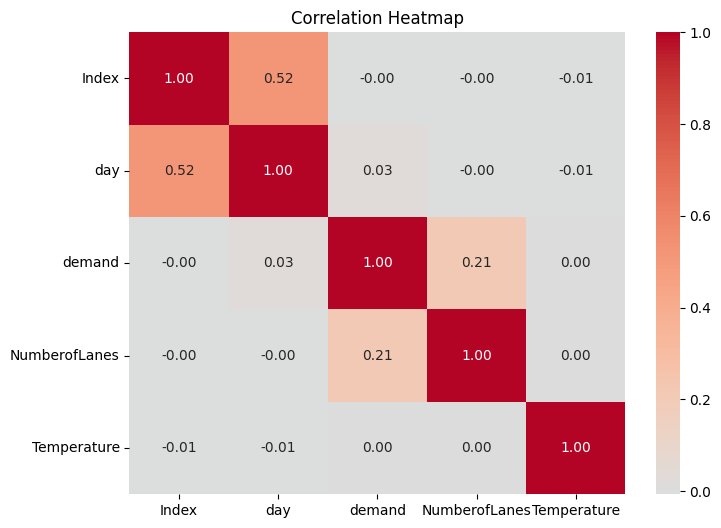

In [14]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

plt.figure(figsize=(8, 6))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

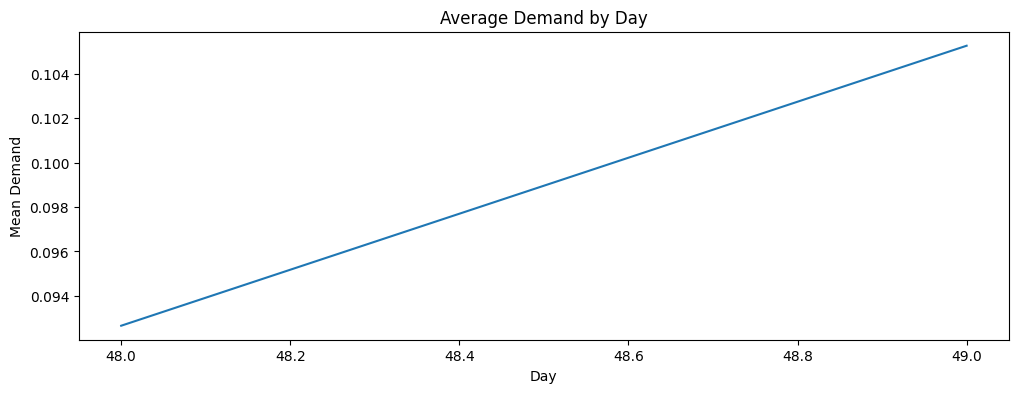

In [15]:
# Demand over Time 
plt.figure(figsize=(12, 4))
train.groupby('day')['demand'].mean().plot()
plt.title('Average Demand by Day')
plt.xlabel('Day')
plt.ylabel('Mean Demand')
plt.show()

Step 3 — Preprocessing & Feature Engineering

In [16]:
# Log Transform on Target
import numpy as np

y = np.log1p(train['demand'])

print("Before log — skewness:", train['demand'].skew())
print("After  log — skewness:", y.skew())

Before log — skewness: 3.7285172887316627
After  log — skewness: 2.9650564544883187


In [17]:
road_mode    = train['RoadType'].mode()[0]
weather_mode = train['Weather'].mode()[0]

temp_median  = train['Temperature'].median()

for df in [train, test]:
    df['RoadType'].fillna(road_mode, inplace=True)
    df['Weather'].fillna(weather_mode, inplace=True)
    df['Temperature'].fillna(temp_median, inplace=True)

print("Nulls remaining in train:")
print(train[['RoadType', 'Temperature', 'Weather']].isnull().sum())
print("\nNulls remaining in test:")
print(test[['RoadType', 'Temperature', 'Weather']].isnull().sum())

Nulls remaining in train:
RoadType        600
Temperature    2495
Weather         797
dtype: int64

Nulls remaining in test:
RoadType        324
Temperature    1349
Weather         431
dtype: int64


C:\Users\ritwi\AppData\Local\Temp\ipykernel_10652\2287610856.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['RoadType'].fillna(road_mode, inplace=True)
C:\Users\ritwi\AppData\Local\Temp\ipykernel_10652\2287610856.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

In [18]:
# Parse Timestamp (format is "2:0" not "2:00")
for df in [train, test]:
    df['hour']   = df['timestamp'].str.split(':').str[0].astype(int)
    df['minute'] = df['timestamp'].str.split(':').str[1].astype(int)
    
    # (15-min buckets → 96 slots in a day)
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    
    # Rush hours: 7–10am and 5–8pm
    df['is_rush_hour'] = df['hour'].apply(
        lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
    )
    
    # Night hours: 10pm–6am
    df['is_night'] = df['hour'].apply(
        lambda x: 1 if (x >= 22 or x <= 6) else 0
    )

print(train[['timestamp','hour','minute','time_slot','is_rush_hour','is_night']].head(8))

  timestamp  hour  minute  time_slot  is_rush_hour  is_night
0       0:0     0       0          0             0         1
1       0:0     0       0          0             0         1
2       0:0     0       0          0             0         1
3       0:0     0       0          0             0         1
4       0:0     0       0          0             0         1
5       0:0     0       0          0             0         1
6       0:0     0       0          0             0         1
7       0:0     0       0          0             0         1


In [19]:
# Encode Binary & Categorical Columns
# LargeVehicles
lv_map = {'Allowed': 1, 'Not Allowed': 0}
train['LargeVehicles'] = train['LargeVehicles'].map(lv_map)
test['LargeVehicles']  = test['LargeVehicles'].map(lv_map)

lm_map = {'Yes': 1, 'No': 0}
train['Landmarks'] = train['Landmarks'].map(lm_map)
test['Landmarks']  = test['Landmarks'].map(lm_map)

# (3 categories)
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
combined_road = pd.concat([train['RoadType'], test['RoadType']])
le.fit(combined_road)
train['RoadType'] = le.transform(train['RoadType'])
test['RoadType']  = le.transform(test['RoadType'])

# (4 categories )
le2 = LabelEncoder()
combined_weather = pd.concat([train['Weather'], test['Weather']])
le2.fit(combined_weather)
train['Weather'] = le2.transform(train['Weather'])
test['Weather']  = le2.transform(test['Weather'])

print("Encoding done!")
print(train[['RoadType','Weather','LargeVehicles','Landmarks']].head())

Encoding done!
   RoadType  Weather  LargeVehicles  Landmarks
0         3        4              0          0
1         1        3              1          1
2         1        3              0          0
3         1        1              0          0
4         1        1              0          0


In [20]:
# Geohash Target Encoding
geohash_mean = train.groupby('geohash')['demand'].mean()
geohash_std  = train.groupby('geohash')['demand'].std()
geohash_max  = train.groupby('geohash')['demand'].max()

train['geo_mean'] = train['geohash'].map(geohash_mean)
train['geo_std']  = train['geohash'].map(geohash_std)
train['geo_max']  = train['geohash'].map(geohash_max)

global_mean = train['demand'].mean()
test['geo_mean'] = test['geohash'].map(geohash_mean).fillna(global_mean)
test['geo_std']  = test['geohash'].map(geohash_std).fillna(0)
test['geo_max']  = test['geohash'].map(geohash_max).fillna(global_mean)

print(train[['geohash','geo_mean','geo_std','geo_max']].head())

  geohash  geo_mean   geo_std   geo_max
0  qp02z1  0.040048  0.030124  0.116299
1  qp02zt  0.208766  0.102870  0.424569
2  qp08bj  0.127931  0.073696  0.332333
3  qp08gt  0.014381  0.010206  0.037525
4  qp02zq  0.029300  0.025563  0.116787


In [21]:
# Geohash x Hour Interaction
geo_hour = train.groupby(['geohash','hour'])['demand'].mean().to_dict()
geo_ts   = train.groupby(['geohash','time_slot'])['demand'].mean().to_dict()

train['geo_hour_demand'] = list(zip(train['geohash'], train['hour']))
train['geo_hour_demand'] = train['geo_hour_demand'].map(geo_hour)

test['geo_hour_demand'] = list(zip(test['geohash'], test['hour']))
test['geo_hour_demand'] = test['geo_hour_demand'].map(geo_hour).fillna(global_mean)

train['geo_ts_demand'] = list(zip(train['geohash'], train['time_slot']))
train['geo_ts_demand'] = train['geo_ts_demand'].map(geo_ts)

test['geo_ts_demand'] = list(zip(test['geohash'], test['time_slot']))
test['geo_ts_demand'] = test['geo_ts_demand'].map(geo_ts).fillna(global_mean)

print(train[['geohash','hour','geo_hour_demand','geo_ts_demand']].head())

  geohash  hour  geo_hour_demand  geo_ts_demand
0  qp02z1     0         0.034855       0.038157
1  qp02zt     0         0.140998       0.114096
2  qp08bj     0         0.068046       0.027132
3  qp08gt     0         0.011243       0.003272
4  qp02zq     0         0.020746       0.010819


In [22]:
!pip install pygeohash -q
import pygeohash as pgh

def decode_geo(gh):
    try:
        lat, lon = pgh.decode(gh)
        return pd.Series([lat, lon])
    except:
        return pd.Series([None, None])

train[['lat','lon']] = train['geohash'].apply(decode_geo)
test[['lat','lon']]  = test['geohash'].apply(decode_geo)

print(train[['geohash','lat','lon']].head())

  geohash       lat        lon
0  qp02z1 -5.484924  90.664673
1  qp02zt -5.462952  90.686646
2  qp08bj -5.462952  90.708618
3  qp08gt -5.462952  90.862427
4  qp02zq -5.457458  90.675659


In [23]:
# Final Feature Selection 
drop_cols = ['geohash', 'timestamp', 'demand', 'Index']

feature_cols = [col for col in train.columns if col not in drop_cols]

X      = train[feature_cols]
y      = np.log1p(train['demand'])   # log-transformed target
X_test = test[feature_cols]

print("Features:", feature_cols)
print("\nX shape     :", X.shape)
print("X_test shape:", X_test.shape)
print("\nAny nulls in X?     ", X.isnull().sum().sum())
print("Any nulls in X_test?", X_test.isnull().sum().sum())

Features: ['day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'time_slot', 'is_rush_hour', 'is_night', 'geo_mean', 'geo_std', 'geo_max', 'geo_hour_demand', 'geo_ts_demand', 'lat', 'lon']

X shape     : (77299, 19)
X_test shape: (41778, 19)

Any nulls in X?      2527
Any nulls in X_test? 1349


In [24]:
# 32 nulls in X
print("Null breakdown in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X = X.fillna(0)

print("\nNulls remaining in X:", X.isnull().sum().sum())
print("Nulls remaining in X_test:", X_test.isnull().sum().sum())

Null breakdown in X:
Temperature    2495
geo_std          32
dtype: int64

Nulls remaining in X: 0
Nulls remaining in X_test: 1349


Step 4 — Train LightGBM Model

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)

X_train: (61839, 19)
X_val  : (15460, 19)


In [26]:
# Train LightGBM
!pip install lightgbm
import lightgbm as lgb
from sklearn.metrics import r2_score

lgb_model = lgb.LGBMRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    max_depth        = 8,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    random_state     = 42,
    n_jobs           = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_val, y_val)],
    callbacks             = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print("\nBest iteration:", lgb_model.best_iteration_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1761
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 19
[LightGBM] [Info] Start training from score 0.083012
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 7.53289e-05
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's l2: 6.91993e-05
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

In [27]:
# (remember to reverse log transform!)
val_preds_log = lgb_model.predict(X_val)
val_preds     = np.expm1(val_preds_log)  
y_val_actual  = np.expm1(y_val)

r2  = r2_score(y_val_actual, val_preds)
score = max(0, 100 * r2)

print(f"R² Score       : {r2:.4f}")
print(f"Competition Score: {score:.2f} / 100")

R² Score       : 0.9944
Competition Score: 99.44 / 100


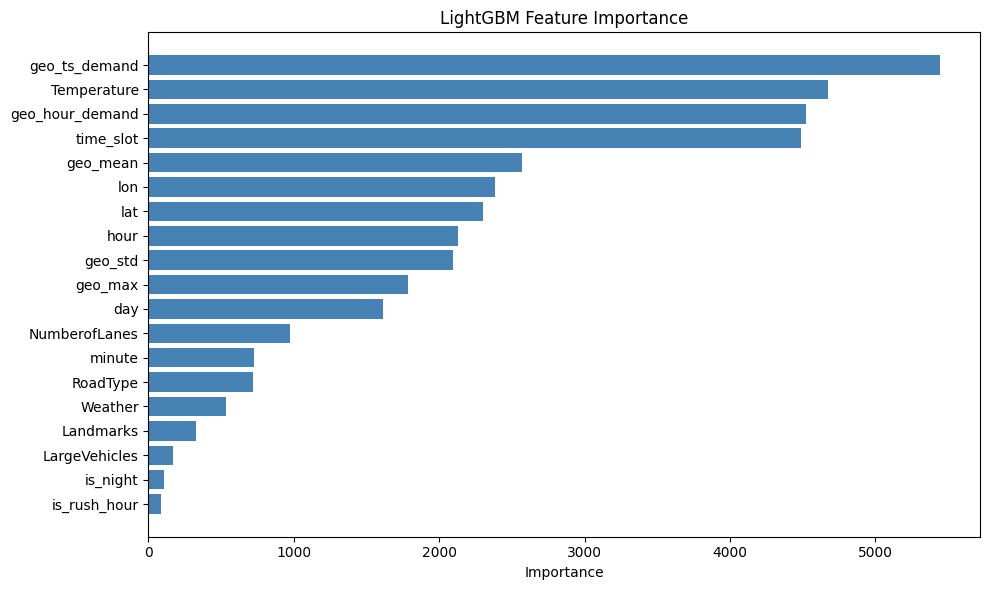

            feature  importance
16    geo_ts_demand        5448
5       Temperature        4678
15  geo_hour_demand        4525
9         time_slot        4491
12         geo_mean        2567
18              lon        2385
17              lat        2298
7              hour        2126
13          geo_std        2096
14          geo_max        1786
0               day        1611
2     NumberofLanes         972
8            minute         724
1          RoadType         720
6           Weather         535
4         Landmarks         325
3     LargeVehicles         167
11         is_night         107
10     is_rush_hour          87


In [28]:
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp)

In [29]:
test_preds_log = lgb_model.predict(X_test)
test_preds     = np.expm1(test_preds_log)  # reverse log transform

# clip negatives to 0 
test_preds = np.clip(test_preds, 0, None)

print("Prediction stats:")
print(pd.Series(test_preds).describe())

Prediction stats:
count    41778.000000
mean         0.129269
std          0.168366
min          0.000000
25%          0.037006
50%          0.083393
75%          0.141492
max          1.048260
dtype: float64


In [30]:
# Redo Target Encoding (No Leakage)
from sklearn.model_selection import KFold

train['geo_mean']         = np.nan
train['geo_ts_demand']    = np.nan
train['geo_hour_demand']  = np.nan

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(train):
    fold_train = train.iloc[train_idx]
    
    _geo_mean      = fold_train.groupby('geohash')['demand'].mean()
    _geo_hour      = fold_train.groupby(['geohash','hour'])['demand'].mean()
    _geo_ts        = fold_train.groupby(['geohash','time_slot'])['demand'].mean()
    
    train.loc[val_idx, 'geo_mean'] = (
        train.iloc[val_idx]['geohash'].map(_geo_mean)
    )
    train.loc[val_idx, 'geo_hour_demand'] = (
        train.iloc[val_idx].set_index(['geohash','hour']).index.map(_geo_hour)
    )
    train.loc[val_idx, 'geo_ts_demand'] = (
        train.iloc[val_idx].set_index(['geohash','time_slot']).index.map(_geo_ts)
    )

# For test set — use full train encodings 
geo_mean_full     = train.groupby('geohash')['demand'].mean()
geo_hour_full     = train.groupby(['geohash','hour'])['demand'].mean()
geo_ts_full       = train.groupby(['geohash','time_slot'])['demand'].mean()

test['geo_mean']        = test['geohash'].map(geo_mean_full).fillna(global_mean)
test['geo_hour_demand'] = (
    test.set_index(['geohash','hour']).index.map(geo_hour_full).fillna(global_mean)
)
test['geo_ts_demand']   = (
    test.set_index(['geohash','time_slot']).index.map(geo_ts_full).fillna(global_mean)
)

train['geo_mean'].fillna(global_mean, inplace=True)
train['geo_hour_demand'].fillna(global_mean, inplace=True)
train['geo_ts_demand'].fillna(global_mean, inplace=True)

print("Done! Nulls in encoding cols:")
print(train[['geo_mean','geo_hour_demand','geo_ts_demand']].isnull().sum())

Done! Nulls in encoding cols:
geo_mean              40
geo_hour_demand     3861
geo_ts_demand      67037
dtype: int64


C:\Users\ritwi\AppData\Local\Temp\ipykernel_10652\1903894726.py:40: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['geo_mean'].fillna(global_mean, inplace=True)
C:\Users\ritwi\AppData\Local\Temp\ipykernel_10652\1903894726.py:41: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assig

In [31]:
# Extra Interaction Features
for df in [train, test]:
    df['day_hour'] = df['day'].astype(str) + '_' + df['hour'].astype(str)
    
    df['temp_bin'] = pd.cut(df['Temperature'], 
                             bins=5, labels=False)
    
    # Lanes x RoadType interaction
    df['lanes_road'] = df['NumberofLanes'] * df['RoadType']
    
    # Is weekend-like? (day 49 seems less data = maybe weekend)
    df['is_day49'] = (df['day'] == 49).astype(int)

# Target encode day_hour
day_hour_mean = train.groupby('day_hour')['demand'].mean()
train['day_hour_demand'] = train['day_hour'].map(day_hour_mean)
test['day_hour_demand']  = test['day_hour'].map(day_hour_mean).fillna(global_mean)

print(train[['day_hour','day_hour_demand','temp_bin','lanes_road']].head())

  day_hour  day_hour_demand  temp_bin  lanes_road
0     48_0          0.05749       NaN           3
1     48_0          0.05749       3.0           3
2     48_0          0.05749       3.0           1
3     48_0          0.05749       NaN           1
4     48_0          0.05749       2.0           1


In [32]:
# K-Fold LightGBM Training
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import lightgbm as lgb

feature_cols = [
    'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks',
    'Temperature', 'Weather', 'hour', 'minute', 'time_slot',
    'is_rush_hour', 'is_night', 'is_day49',
    'geo_mean', 'geo_std', 'geo_max',
    'geo_hour_demand', 'geo_ts_demand', 'day_hour_demand',
    'lat', 'lon', 'temp_bin', 'lanes_road'
]

X      = train[feature_cols].fillna(0)
y      = np.log1p(train['demand'])
X_test = test[feature_cols].fillna(0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds   = np.zeros(len(X))
test_preds  = np.zeros(len(X_test))
scores      = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(
        n_estimators      = 2000,
        learning_rate     = 0.03,
        max_depth         = 8,
        num_leaves        = 127,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 20,
        reg_alpha         = 0.1,
        reg_lambda        = 0.1,
        random_state      = 42,
        n_jobs            = -1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(100), lgb.log_evaluation(200)]
    )
    
    # OOF predictions
    oof_preds[val_idx] = model.predict(X_val)
    
    # Test predictions (average across folds)
    test_preds += model.predict(X_test) / 5
    
    # Score
    fold_r2 = r2_score(np.expm1(y_val), np.expm1(oof_preds[val_idx]))
    scores.append(fold_r2)
    print(f"Fold {fold+1} R²: {fold_r2:.4f} | Score: {fold_r2*100:.2f}")

print(f"\n Mean CV R²    : {np.mean(scores):.4f}")
print(f"Mean CV Score : {np.mean(scores)*100:.2f} / 100")


--- Fold 1 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 23
[LightGBM] [Info] Start training from score 0.083012
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [33]:
# Cyclical Encoding for Hour & Time Slot

for df in [train, test]:
    # Hour cycles over 24
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Time slot cycles over 96
    df['ts_sin'] = np.sin(2 * np.pi * df['time_slot'] / 96)
    df['ts_cos'] = np.cos(2 * np.pi * df['time_slot'] / 96)
    
    # Minute cycles over 60
    df['min_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
    df['min_cos'] = np.cos(2 * np.pi * df['minute'] / 60)

print(train[['hour','hour_sin','hour_cos','ts_sin','ts_cos']].head(8))

   hour  hour_sin  hour_cos  ts_sin  ts_cos
0     0       0.0       1.0     0.0     1.0
1     0       0.0       1.0     0.0     1.0
2     0       0.0       1.0     0.0     1.0
3     0       0.0       1.0     0.0     1.0
4     0       0.0       1.0     0.0     1.0
5     0       0.0       1.0     0.0     1.0
6     0       0.0       1.0     0.0     1.0
7     0       0.0       1.0     0.0     1.0


In [34]:
# Geohash Hierarchy Features
# Geohash prefix = broader geographic area
for df in [train, test]:
    df['geo_prefix_4'] = df['geohash'].str[:4]  # neighbourhood level
    df['geo_prefix_3'] = df['geohash'].str[:3]  # city level
    df['geo_prefix_2'] = df['geohash'].str[:2]  # region level

for prefix in ['geo_prefix_4', 'geo_prefix_3', 'geo_prefix_2']:
    prefix_mean = train.groupby(prefix)['demand'].mean()
    train[f'{prefix}_demand'] = train[prefix].map(prefix_mean)
    test[f'{prefix}_demand']  = test[prefix].map(prefix_mean).fillna(global_mean)

print(train[['geohash','geo_prefix_4','geo_prefix_3',
             'geo_prefix_4_demand','geo_prefix_3_demand']].head())

  geohash geo_prefix_4 geo_prefix_3  geo_prefix_4_demand  geo_prefix_3_demand
0  qp02z1         qp02          qp0             0.139909             0.093942
1  qp02zt         qp02          qp0             0.139909             0.093942
2  qp08bj         qp08          qp0             0.056277             0.093942
3  qp08gt         qp08          qp0             0.056277             0.093942
4  qp02zq         qp02          qp0             0.139909             0.093942


In [35]:
for df in [train, test]:
    df['temp_weather'] = df['Temperature'] * df['Weather']
    
    df['lat_lanes']  = df['lat'] * df['NumberofLanes']
    df['lon_lanes']  = df['lon'] * df['NumberofLanes']
    
    df['rush_road']  = df['is_rush_hour'] * df['RoadType']
    
    df['night_lv']   = df['is_night'] * df['LargeVehicles']

print("New features added!")
print(train[['temp_weather','lat_lanes','rush_road','night_lv']].head())

New features added!
   temp_weather  lat_lanes  rush_road  night_lv
0           NaN  -5.484924          0         0
1     93.313694 -16.388855          0         1
2     77.757802  -5.462952          0         0
3           NaN  -5.462952          0         0
4     10.803667  -5.457458          0         0


In [36]:
feature_cols = [
    'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks',
    'Temperature', 'Weather',
    
    'hour', 'minute', 'time_slot',
    'is_rush_hour', 'is_night', 'is_day49',
    'hour_sin', 'hour_cos', 'ts_sin', 'ts_cos', 'min_sin', 'min_cos',
    
    'lat', 'lon',
    
    'geo_mean', 'geo_std', 'geo_max',
    'geo_hour_demand', 'geo_ts_demand', 'day_hour_demand',
    'geo_prefix_4_demand', 'geo_prefix_3_demand', 'geo_prefix_2_demand',
    
    'temp_weather', 'lat_lanes', 'lon_lanes',
    'rush_road', 'night_lv', 'lanes_road', 'temp_bin'
]

X      = train[feature_cols].fillna(0)
y      = np.log1p(train['demand'])
X_test = test[feature_cols].fillna(0)

print(f"Total features: {len(feature_cols)}")
print("Nulls in X:", X.isnull().sum().sum())
print("Nulls in X_test:", X_test.isnull().sum().sum())

Total features: 37
Nulls in X: 0
Nulls in X_test: 0


In [37]:
# LightGBM KFold (Tuned)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lgb_oof   = np.zeros(len(X))
lgb_test  = np.zeros(len(X_test))
scores    = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(
        n_estimators      = 3000,
        learning_rate     = 0.02,
        max_depth         = 10,
        num_leaves        = 255,
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        min_child_samples = 15,
        reg_alpha         = 0.05,
        reg_lambda        = 0.05,
        random_state      = 42,
        n_jobs            = -1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(100), lgb.log_evaluation(500)]
    )
    
    lgb_oof[val_idx] = model.predict(X_val)
    lgb_test        += model.predict(X_test) / 5
    
    fold_r2 = r2_score(np.expm1(y_val), np.expm1(lgb_oof[val_idx]))
    scores.append(fold_r2)
    print(f"Fold {fold+1} R²: {fold_r2:.4f} | Score: {fold_r2*100:.2f}")

print(f"\nLightGBM CV Score: {np.mean(scores)*100:.2f} / 100")


--- Fold 1 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2618
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 35
[LightGBM] [Info] Start training from score 0.083012
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [38]:
!pip install xgboost
from xgboost import XGBRegressor

xgb_oof  = np.zeros(len(X))
xgb_test = np.zeros(len(X_test))
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBRegressor(
        n_estimators      = 3000,
        learning_rate     = 0.02,
        max_depth         = 8,
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        reg_alpha         = 0.05,
        reg_lambda        = 0.05,
        random_state      = 42,
        n_jobs            = -1,
        early_stopping_rounds = 100,
        eval_metric       = 'rmse'
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        verbose   = 500
    )
    
    xgb_oof[val_idx] = model.predict(X_val)
    xgb_test        += model.predict(X_test) / 5
    
    fold_r2 = r2_score(np.expm1(y_val), np.expm1(xgb_oof[val_idx]))
    xgb_scores.append(fold_r2)
    print(f"Fold {fold+1} R²: {fold_r2:.4f} | Score: {fold_r2*100:.2f}")

print(f"\nXGBoost CV Score: {np.mean(xgb_scores)*100:.2f} / 100")


--- Fold 1 ---
[0]	validation_0-rmse:0.10721
[500]	validation_0-rmse:0.02299
[906]	validation_0-rmse:0.02296
Fold 1 R²: 0.9611 | Score: 96.11

--- Fold 2 ---
[0]	validation_0-rmse:0.10852
[500]	validation_0-rmse:0.02339
[759]	validation_0-rmse:0.02335
Fold 2 R²: 0.9610 | Score: 96.10

--- Fold 3 ---
[0]	validation_0-rmse:0.10657
[500]	validation_0-rmse:0.02243
[864]	validation_0-rmse:0.02243
Fold 3 R²: 0.9641 | Score: 96.41

--- Fold 4 ---
[0]	validation_0-rmse:0.10475
[500]	validation_0-rmse:0.02322
[670]	validation_0-rmse:0.02322
Fold 4 R²: 0.9585 | Score: 95.85

--- Fold 5 ---
[0]	validation_0-rmse:0.10723
[500]	validation_0-rmse:0.02264
[727]	validation_0-rmse:0.02263
Fold 5 R²: 0.9637 | Score: 96.37

XGBoost CV Score: 96.17 / 100


In [39]:
# 60% LGB + 40% XGB 
blend = 0.6 * lgb_test + 0.4 * xgb_test

final_preds = np.expm1(blend)
final_preds = np.clip(final_preds, 0, None)

oof_blend = 0.6 * lgb_oof + 0.4 * xgb_oof
oof_r2    = r2_score(np.expm1(y), np.expm1(oof_blend))
print(f"Blended OOF Score: {oof_r2*100:.2f} / 100")

Blended OOF Score: 96.17 / 100


In [40]:
submission = pd.DataFrame({
    'Index' : test['Index'],
    'demand': final_preds
})

submission.to_csv('submission_v3.csv', index=False)

print("Shape     :", submission.shape)
print("Nulls     :", submission.isnull().sum().sum())
print("Negatives :", (submission['demand'] < 0).sum())
print(submission.head())

Shape     : (41778, 2)
Nulls     : 0
Negatives : 0
   Index    demand
0      0  0.052196
1      1  0.028919
2      2  0.045961
3      3  0.045658
4      4  0.043536
